In [1]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import getpass

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb

print("Imports loaded")

Imports loaded


In [2]:
conn = snowflake.connector.connect(
    user=input("Snowflake username: "),
    password=getpass.getpass("Snowflake password: "),
    account=input("Account identifier: "),
    warehouse='CMS_WH',
    database='CMS_PROJECT',
    schema='REVENUE_CYCLE'
)

query = "SELECT * FROM MEDICARE_PROVIDER_SERVICE SAMPLE (500000 ROWS)"
df = pd.read_sql(query, conn)


df['LEAKAGE']      = df['AVG_SBMTD_CHRG'] - df['AVG_MDCR_PYMT_AMT']
df['LEAKAGE_RATE'] = df['LEAKAGE'] / df['AVG_SBMTD_CHRG']
df['TOTAL_LEAKAGE'] = df['LEAKAGE_RATE']*df['TOT_SRVCS']
df['PAYMENT_RATIO'] = df['AVG_MDCR_PYMT_AMT']/df['AVG_SBMTD_CHRG']
df['PATIENT_COST_SHARE'] = df['AVG_MDCR_ALOWD_AMT'] - df['AVG_MDCR_PYMT_AMT']

threshold = df['LEAKAGE_RATE'].quantile(0.75)
df['DENIAL_PROXY'] = (df['LEAKAGE_RATE'] > threshold).astype(int)


df['IS_FACILITY']        = (df['PLACE_OF_SRVC'] == 'F').astype(int)
df['IS_DRUG']            = (df['HCPCS_DRUG_IND'] == 'Y').astype(int)
df['IS_PARTICIPATING']   = (df['RNDRNG_PRVDR_MDCR_PRTCPTG_IND'] == 'Y').astype(int)
df['PROVIDER_TYPE_FREQ'] = df['RNDRNG_PRVDR_TYPE'].map(
    df['RNDRNG_PRVDR_TYPE'].value_counts(normalize=True))
df['STATE_FREQ']         = df['RNDRNG_PRVDR_STATE_ABRVTN'].map(
    df['RNDRNG_PRVDR_STATE_ABRVTN'].value_counts(normalize=True))

print(f"Rows: {df.shape[0]:,}  |  Threshold: {threshold:.2%}")
print(df['DENIAL_PROXY'].value_counts())

Snowflake username:  shantanunayar
Snowflake password:  ········
Account identifier:  QHJNHYN-WZ62559


/var/folders/10/cg68x6sj1rx_46lzjx372ycc0000gn/T/ipykernel_11727/3264792383.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Rows: 500,000  |  Threshold: 83.16%
DENIAL_PROXY
0    375000
1    125000
Name: count, dtype: int64


In [3]:


candidate_features = [
 
    'AVG_SBMTD_CHRG', 'AVG_MDCR_ALOWD_AMT', 'AVG_MDCR_PYMT_AMT', 'AVG_MDCR_STDZD_AMT',

    'LEAKAGE', 'LEAKAGE_RATE', 'TOTAL_LEAKAGE', 'PAYMENT_RATIO', 'PATIENT_COST_SHARE',
   
    'TOT_BENES', 'TOT_SRVCS', 'TOT_BENE_DAY_SRVCS',
   
    'IS_FACILITY', 'IS_DRUG', 'IS_PARTICIPATING', 'PROVIDER_TYPE_FREQ', 'STATE_FREQ'
]

print(f"Candidate features: {len(candidate_features)}")

Candidate features: 17


In [4]:
target_corr = (df[candidate_features + ['DENIAL_PROXY']]
               .corr()['DENIAL_PROXY']
               .drop('DENIAL_PROXY')
               .sort_values(key=abs, ascending=False))

corr_table = pd.DataFrame({'Corr_with_Target': target_corr.round(3)})
corr_table['Flag'] = pd.cut(
    corr_table['Corr_with_Target'].abs(),
    bins=[0, 0.5, 0.9, 1.0],
    labels=['OK', 'Suspicious', 'LEAKAGE']
)

print(corr_table)

                    Corr_with_Target        Flag
LEAKAGE_RATE                   0.568  Suspicious
PAYMENT_RATIO                 -0.568  Suspicious
IS_FACILITY                    0.268          OK
LEAKAGE                        0.207          OK
AVG_SBMTD_CHRG                 0.178          OK
PROVIDER_TYPE_FREQ             0.036          OK
STATE_FREQ                     0.028          OK
IS_DRUG                        0.012          OK
AVG_MDCR_STDZD_AMT            -0.010          OK
AVG_MDCR_PYMT_AMT             -0.009          OK
TOTAL_LEAKAGE                  0.008          OK
IS_PARTICIPATING               0.008          OK
AVG_MDCR_ALOWD_AMT            -0.008          OK
TOT_BENES                      0.003          OK
TOT_BENE_DAY_SRVCS            -0.002          OK
PATIENT_COST_SHARE            -0.002          OK
TOT_SRVCS                      0.001          OK


In [5]:
feature_cols = [
    'AVG_SBMTD_CHRG',       
    'TOT_BENES',
    'TOT_SRVCS',
    'TOT_BENE_DAY_SRVCS',
    'IS_FACILITY',
    'IS_DRUG',
    'IS_PARTICIPATING',
    'PROVIDER_TYPE_FREQ',
    'STATE_FREQ',
]

In [6]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df[feature_cols], df['DENIAL_PROXY'], random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mutual_Info': mi_scores
}).sort_values('Mutual_Info', ascending=False)

print(mi_df.round(4))

              Feature  Mutual_Info
0      AVG_SBMTD_CHRG       0.0999
7  PROVIDER_TYPE_FREQ       0.0903
4         IS_FACILITY       0.0558
6    IS_PARTICIPATING       0.0558
8          STATE_FREQ       0.0130
3  TOT_BENE_DAY_SRVCS       0.0075
2           TOT_SRVCS       0.0053
1           TOT_BENES       0.0027
5             IS_DRUG       0.0019


In [7]:
print("Denial rate by place of service:")
print(df.groupby('IS_FACILITY')['DENIAL_PROXY'].mean().round(3))

print("\nDenial rate by drug indicator:")
print(df.groupby('IS_DRUG')['DENIAL_PROXY'].mean().round(3))

print("\nTop 10 provider types by denial rate (min 500 claims):")
prov = (df.groupby('RNDRNG_PRVDR_TYPE')
          .agg(denial_rate=('DENIAL_PROXY', 'mean'),
               n=('DENIAL_PROXY', 'size'))
          .query('n >= 500')
          .sort_values('denial_rate', ascending=False)
          .head(10))
print(prov.round(3))

Denial rate by place of service:
IS_FACILITY
0    0.164
1    0.407
Name: DENIAL_PROXY, dtype: float64

Denial rate by drug indicator:
IS_DRUG
0    0.249
1    0.272
Name: DENIAL_PROXY, dtype: float64

Top 10 provider types by denial rate (min 500 claims):
                                                denial_rate      n
RNDRNG_PRVDR_TYPE                                                 
Certified Registered Nurse Anesthetist (CRNA)         0.899   5921
Anesthesiology                                        0.836  10336
Emergency Medicine                                    0.622  10917
Independent Diagnostic Testing Facility (IDTF)        0.611   1571
Ambulatory Surgical Center                            0.494   3148
Diagnostic Radiology                                  0.481  57094
Interventional Radiology                              0.453   3052
Pain Management                                       0.441   2351
Interventional Pain Management                        0.418   1293
Patholog

In [8]:
feature_cols = [
    'AVG_SBMTD_CHRG',
    'TOT_BENES',
    'TOT_SRVCS',
    'TOT_BENE_DAY_SRVCS',
    'IS_FACILITY',
    'IS_DRUG',
    'IS_PARTICIPATING',
    'PROVIDER_TYPE_FREQ',
    'STATE_FREQ',
]

X = df[feature_cols]
y = df['DENIAL_PROXY']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate:  {y_test.mean():.2%}")

Train: 400,000 rows
Test:  100,000 rows
Train positive rate: 25.00%
Test positive rate:  25.00%


In [9]:
scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'auc',
    random_state = 42,
    n_jobs = 1
)

model.fit(
    X_train, y_train, eval_set = [(X_train, y_train), (X_test,y_test)], verbose = 50
)

print("\nTrained")

scale_pos_weight: 3.00
[0]	validation_0-auc:0.79505	validation_1-auc:0.79412
[50]	validation_0-auc:0.84327	validation_1-auc:0.84087
[100]	validation_0-auc:0.85650	validation_1-auc:0.85328
[150]	validation_0-auc:0.86227	validation_1-auc:0.85801
[200]	validation_0-auc:0.86702	validation_1-auc:0.86172
[250]	validation_0-auc:0.87138	validation_1-auc:0.86536
[299]	validation_0-auc:0.87378	validation_1-auc:0.86684

Trained


ROC_AUC: 0.8668

              precision    recall  f1-score   support

    Low Risk       0.91      0.82      0.86     75000
   High Risk       0.58      0.74      0.65     25000

    accuracy                           0.80    100000
   macro avg       0.74      0.78      0.76    100000
weighted avg       0.82      0.80      0.81    100000



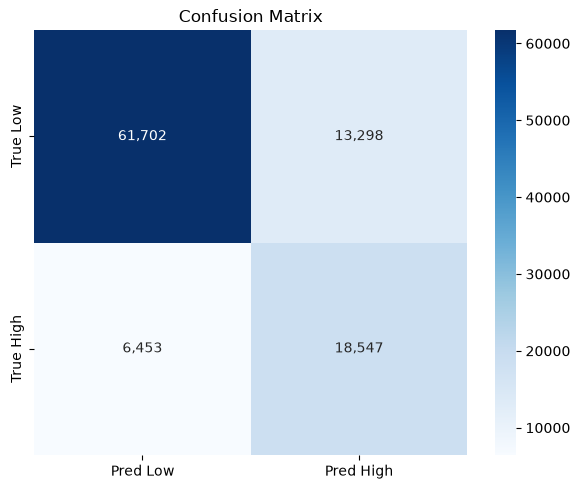

In [10]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"ROC_AUC: {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names = ['Low Risk', 'High Risk']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Pred Low', 'Pred High'],
            yticklabels=['True Low', 'True High'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
                            
                            